In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Mount Google Drive (if you're using Google Colab)
from google.colab import drive
drive.mount('/content/drive')

# Load your dataset (replace with the actual path of your CSV file)
df = pd.read_csv("/content/drive/MyDrive/youtube_data_cleaned.csv")

# Assume last column is the target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

column_name = df.columns[-1]
print(f"The name of the target column is: {column_name}")

# 1. Preprocessing: Handle non-numeric data
# One-hot encoding for categorical columns in X (if any categorical columns exist)
X = pd.get_dummies(X, drop_first=True)

# Clean column names to remove any invalid characters
X.columns = [str(col).replace("[", "").replace("]", "").replace(",", "").replace("<", "").replace(">", "_") for col in X.columns]

# Label encoding for target variable 'y' if it's categorical (e.g., binary classification)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Convert y to a pandas Series for handling missing values
y = pd.Series(y)

# Handle missing values in target variable 'y' (if any)
y = y.fillna(y.mean())  # Filling missing values in target with the mean

# 2. Handle missing values in X by filling with mean
X = X.fillna(X.mean())  # Filling missing values in features

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Define the regression models to evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "XGBoost Regressor": XGBRegressor(objective='reg:squarederror', random_state=42)
}

# 5. Store the results for each model
results = []

# 6. Evaluate each model
for name, model in models.items():
    start = time.time()  # Start the timer
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Make predictions
    end = time.time()  # End the timer

    # Avoid division by zero in MAPE calculation
    non_zero_indices = y_test != 0
    y_test_non_zero = y_test[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    mape = np.mean(np.abs((y_test_non_zero - y_pred_non_zero) / y_test_non_zero)) * 100

    # Append model results to the list
    results.append({
        "Model": name,
        "R² Score": round(r2_score(y_test, y_pred), 4),
        "MAE": round(mean_absolute_error(y_test, y_pred), 4),
        "MAPE (%)": round(mape, 2),
        "Train Time (s)": round(end - start, 3)
    })

# 7. Convert results to a DataFrame and sort by MAE (Mean Absolute Error)
results_df = pd.DataFrame(results).sort_values(by="MAE")

# 8. Display the model evaluation summary
print("\n🔍 Model Evaluation Summary:")
print(results_df.to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
The name of the target column is: Will_Trend


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:252: LinAlgWarning: Ill-conditioned matrix (rcond=3.00356e-17): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.297e+00, tolerance: 1.684e-03
  model = cd_fast.enet_coordinate_descent(



🔍 Model Evaluation Summary:
                   Model  R² Score    MAE  MAPE (%)  Train Time (s)
           Decision Tree    1.0000 0.0000      0.00           0.030
       XGBoost Regressor    1.0000 0.0000      0.02           0.322
           Random Forest    0.9246 0.0138      4.50           0.185
Support Vector Regressor   -0.0609 0.1382     90.00           0.029
        Ridge Regression   -0.0405 0.1572     28.68           0.103
       Linear Regression   -0.3818 0.1726     31.12           0.043
        Lasso Regression   -0.0906 0.1732     78.10           0.095


Index(['Title', 'Views', 'Upload Date', 'Likes', 'Comments', 'Hashtags',
       'Duration_min', 'Duration_Category', 'Trending_Hashtags_Count',
       'Has_Trending_Hashtags', 'Upload_Year', 'Like_Ratio', 'Comment_Ratio',
       'Engagement_Score', 'Title_Length', 'Title_Word_Count',
       'Title_Has_Question', 'Will_Trend'],
      dtype='object')
Column 'Will_Trend' not found in the dataset!
📈 XGBoost Cross-Validation R² Mean Score: 0.9529

📊 Model Performance Summary:

                 Model  R² Score       MAE      MAPE (%)  Train Time (s)
0    Linear Regression -0.093056  0.176577  1.599486e+11        0.002150
1     Ridge Regression -0.054892  0.171469  1.550977e+11        0.001767
2     Lasso Regression -0.096497  0.150556  1.083547e+11        0.001687
3        Decision Tree  1.000000  0.000000  9.523810e+01        0.001643
4        Random Forest  0.921932  0.015000  1.285714e+10        0.240345
5  Tuned Random Forest  0.944770  0.011905  1.047619e+10        8.730122
6           

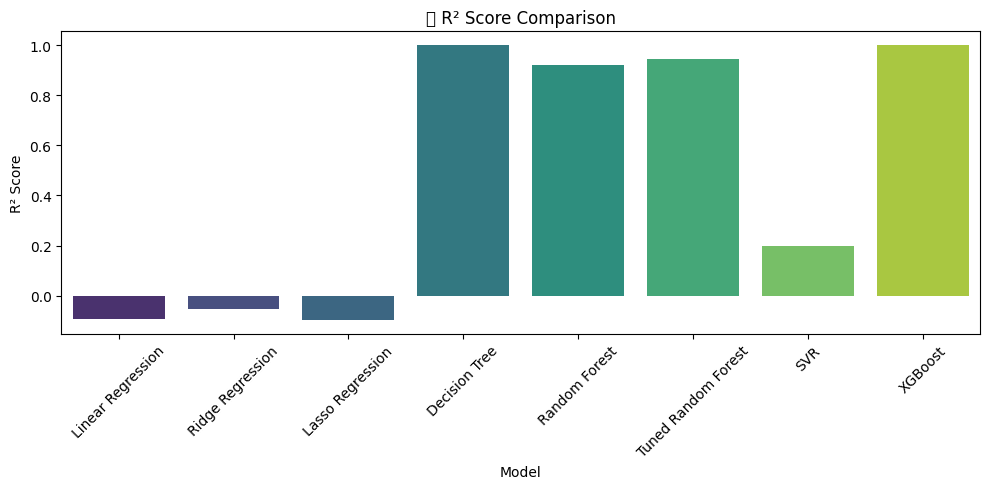

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

# Load your dataset (replace with your path)
df = pd.read_csv('/content/drive/MyDrive/youtube_data_cleaned.csv')  # <-- update this to your file

# Clean column names to remove any extra spaces
df.columns = df.columns.str.strip()

# Verify column names
print(df.columns)

# Preprocessing
df = df.select_dtypes(include=[np.number]).dropna()  # Keep only numeric columns

# Check if 'Will_Trend' exists
if 'Will_Trend' in df.columns:
    X = df.drop(columns=['Will_Trend'])  # Replace 'Will_Trend' with your actual target column
    y = df['Will_Trend']
else:
    print("Column 'Will_Trend' not found in the dataset!")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Tuned Random Forest': GridSearchCV(RandomForestRegressor(), {
        'n_estimators': [50, 100],
        'max_depth': [None, 10]
    }, cv=3, n_jobs=-1),
    'SVR': SVR(),
    'XGBoost': XGBRegressor(verbosity=0)
}

# Evaluation Function
def evaluate_model(name, model):
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start
    y_pred = model.predict(X_test_scaled)

    # Safe MAPE calculation
    y_test_safe = y_test.copy()
    y_test_safe[y_test_safe == 0] = 1e-10
    try:
        mape = mean_absolute_percentage_error(y_test_safe, y_pred) * 100
    except:
        mape = float('inf')

    return {
        'Model': name,
        'R² Score': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MAPE (%)': mape,
        'Train Time (s)': train_time
    }

# Evaluate all models
results = [evaluate_model(name, model) for name, model in models.items()]
df_results = pd.DataFrame(results)

# Cross-validation for XGBoost
xgb = XGBRegressor(verbosity=0)
xgb_scores = cross_val_score(xgb, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"📈 XGBoost Cross-Validation R² Mean Score: {xgb_scores.mean():.4f}")

# 📊 Display results
print("\n📊 Model Performance Summary:\n")
print(df_results)

# 📍 Plot the R² scores
plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x='Model', y='R² Score', palette='viridis')
plt.title("📍 R² Score Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
